<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH11/CH11_NB02_BBQ_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Rearchitecting LLMs
### Structural techniques for efficient models

Chapter 11: Fairness-Aware Pruning — NB02: BBQ Benchmark

[LinkedIn](https://www.linkedin.com/in/peremartra/) | [GitHub](https://github.com/peremartra) | [X](https://x.com/PereMartra) | [Hugging Face](https://huggingface.co/oopere)

---

Colab Environment: GPU L4 (also runs on T4, only slower)

Model:
* `meta-llama/Llama-3.2-1B` — the model we instrument and intervene on

---

This notebook measures whether the neuron intervention from Chapter 11 (EXPLICIT_SCALES, the Top-5 neurons selected on the police-encounter prompt pair) has any measurable effect on a standard bias benchmark, rather than on the handful of hand-picked prompts used earlier in the chapter.

We use [BBQ](https://github.com/nyu-mll/BBQ) (Bias Benchmark for QA), and specifically its race/ethnicity bias score, since that is the axis the intervention targets. In the installed version of lm-evaluation-harness, BBQ is a single task covering all nine bias categories at once, the per-category breakdown, including race/ethnicity, is reported as extra metrics within that one run rather than as a separate task. There is no way to evaluate the race/ethnicity slice on its own, so each run below covers the full BBQ suite (roughly 58,000 examples). BBQ presents a context, a question, and three answer choices (the stereotyped group, the other group, and an unknown option), in two variants: an ambiguous context, where the correct answer is always unknown, and a disambiguated context, where the correct answer can be determined. For each variant and each category, BBQ reports a bias score, the rate at which the model's answer reflects the stereotype rather than the correct or unknown answer. Accuracy is only reported as an aggregate across all nine categories, not broken down by category, so this notebook compares bias score only.

We run this benchmark twice on `meta-llama/Llama-3.2-1B`, once with the original weights and once with `EXPLICIT_SCALES` applied, and compare the two runs. This notebook does not repeat any of the activation-capture or SignedScore machinery from NB01. It only reloads the model, reapplies the same five-neuron intervention, and runs it through a standard benchmark.

# Setup

This section installs `lm-evaluation-harness`, the framework we use to run BBQ, and loads the model. Everything here is copied from NB01 without modification, since the point of this notebook is to reuse the same model and the same intervention, not to build new infrastructure.

In [ ]:
!pip install -q transformers torch lm_eval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 157.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.5 MB/s eta 0:00:00


In [ ]:
import copy
import random
from typing import Dict, Tuple

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


Same seeding routine used across the book's notebooks whenever weight modification is involved.

In [ ]:
def set_seed(seed=42):
    """Set random seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
print("Random seed set to 42")

Random seed set to 42


In [ ]:
MODEL_ID = "meta-llama/Llama-3.2-1B"

# How many examples to sample per BBQ context (ambiguous / disambiguated) for a quick run.
# lm-eval only exposes race/ethnicity metrics as a breakdown inside the full "bbq" task
# (all nine categories, roughly 58,000 examples); there is no way to run race/ethnicity
# on its own. Set to None for the full suite.
# Start with a small limit to measure the per-example time on T4 before committing to a full run.
BBQ_LIMIT = 25000

print(f"MODEL_ID: {MODEL_ID}")
print(f"BBQ_LIMIT: {BBQ_LIMIT}")

MODEL_ID: meta-llama/Llama-3.2-1B
BBQ_LIMIT: 25000


In [ ]:
print(f"Loading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print(f"Loading model: {MODEL_ID}")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
)
model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print(f"  Layers: {model.config.num_hidden_layers}")
print(f"  Hidden size: {model.config.hidden_size}")

# Kept in memory so we can restore the model between the baseline and intervened runs
# without reloading from disk each time (see NB01, section 11.5).
original_state_dict = copy.deepcopy(model.state_dict())

Loading tokenizer: meta-llama/Llama-3.2-1B


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Model loaded.
  Layers: 16
  Hidden size: 2048


# Reapplying the race intervention

`get_model_layers`, `apply_explicit_scales`, and `restore_model` are unchanged from NB01, sections 11.1 and 11.5. `EXPLICIT_SCALES` is the same Top-5 neuron set selected in section 11.4 on the police-encounter prompt pair, scaled down by the same factor of 0.1. Nothing here is recomputed, we only reapply the intervention NB01 already validated on individual prompts.

In [ ]:
def get_model_layers(model):
    """Resolve the list of transformer decoder layers across common architectures."""
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return model.transformer.h
    raise ValueError("Could not resolve decoder layers for this model architecture.")


def apply_explicit_scales(model, scales: Dict[Tuple[int, int], float]):
    """
    Apply an explicit per-neuron scale factor to gate_proj (row), up_proj (row),
    and down_proj (column) for each (layer_idx, neuron_idx) key in `scales`.
    """
    layers = get_model_layers(model)
    with torch.no_grad():
        for (layer_idx, neuron_idx), scale in scales.items():
            mlp = layers[layer_idx].mlp
            #mlp.gate_proj.weight.data[neuron_idx, :] *= scale
            mlp.up_proj.weight.data[neuron_idx, :] *= scale
            #mlp.down_proj.weight.data[:, neuron_idx] *= scale
    return model


def restore_model():
    model.load_state_dict(original_state_dict)
    model.eval()

In [ ]:
# Race-intervention neurons, Top-5 by |SignedScore| on the police-encounter pair (NB01, section 11.4).
EXPLICIT_SCALES = {
    (15, 1788): 0.1,  # positive-difference
    (15, 1070): 0.1,  # negative-difference
    (15, 8109): 0.1,  # positive-difference
    (15, 2719): 0.1,  # positive-difference
    (15, 3024): 0.1,  # positive-difference
}

# 11.4 Benchmarking the intervened models
## 11.4.2 Measuring bias with BBQ

`run_bbq` wraps the already-loaded `model` and `tokenizer` in lm-evaluation-harness's `HFLM` adapter and runs the `bbq` task, zero-shot. This is the full BBQ suite, all nine bias categories, since the installed lm-eval version does not register race/ethnicity as a separate task; the race/ethnicity bias scores are reported as extra metrics inside this one run, under keys with a `_Race_ethnicity` suffix. We deliberately do not reuse this book's shared `model_evaluation` helper here. That helper only keeps a fixed list of metric names (accuracy, accuracy norm, perplexity, f1, exact match), and BBQ's own `acc` metric matches one of those names, so the helper stops there and silently drops the bias-score metrics we actually need. `run_bbq` reads the metrics we care about directly from the raw results dictionary instead, and prints that raw dictionary once so the exact key names can be checked against whatever lm-eval version is installed.

In [ ]:
def run_bbq(model, tokenizer, limit=None, show_raw=False):
    """
    Evaluate the model on the full BBQ suite (all nine categories), zero-shot.

    lm-eval only exposes a per-category breakdown for the bias-score metrics, not for
    accuracy, so this returns the race/ethnicity bias scores plus the overall (all-category)
    accuracy. Set show_raw=True once to inspect the full metrics dictionary lm-eval returns,
    in case key names differ across lm-eval versions.
    """
    from lm_eval import evaluator
    from lm_eval.models.huggingface import HFLM

    model_wrapper = HFLM(pretrained=model, tokenizer=tokenizer, device=DEVICE)
    results = evaluator.simple_evaluate(
        model=model_wrapper,
        tasks=["bbq"],
        num_fewshot=0,
        limit=limit,
        device=DEVICE,
        batch_size="auto",
        max_batch_size=256,
    )
    res = results["results"]["bbq"]

    if show_raw:
        print("Raw bbq metrics:")
        for key, value in res.items():
            print(f"  {key}: {value}")

    return {
        "acc": res["acc,none"],
        "amb_bias_score_race": res["amb_bias_score_Race_ethnicity,none"],
        "disamb_bias_score_race": res["disamb_bias_score_Race_ethnicity,none"],
    }

Now the same evaluation with `EXPLICIT_SCALES` applied. No recomputation of the intervention itself, the five neurons and the 0.1 scale factor are exactly the ones validated in NB01.

In [ ]:
apply_explicit_scales(model, EXPLICIT_SCALES)

race_bbq = run_bbq(model, tokenizer, limit=BBQ_LIMIT)

print("Intervened BBQ (race/ethnicity):")
for key, value in race_bbq.items():
    print(f"  {key}: {value:+.4f}")

README.md:   0%|          | 0.00/3.22k [00:00<?, ?B/s]

data/All.jsonl: reconstructing file:   0%|          |  0.00B / 50.9MB            

data/All.jsonl: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/58492 [00:00<?, ? examples/s]

Map:   0%|          | 0/58492 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 300000/300000 [1:37:42<00:00, 51.17it/s] 


Intervened BBQ (race/ethnicity):
  acc: +0.2924
  amb_bias_score_race: -0.0047
  disamb_bias_score_race: +0.0017


We restore the original weights, then run `run_bbq` with `show_raw=True` so the raw metric names are visible before we rely on them for the intervened run and the chart.

In [ ]:
restore_model()

baseline_bbq = run_bbq(model, tokenizer, limit=BBQ_LIMIT, show_raw=True)

print("\nBaseline BBQ (race/ethnicity):")
for key, value in baseline_bbq.items():
    print(f"  {key}: {value:+.4f}")

Running loglikelihood requests: 100%|██████████| 300000/300000 [1:38:01<00:00, 51.01it/s] 


Raw bbq metrics:
  name: bbq
  alias: bbq
  sample_len: 25000
  acc,none: 0.29296
  acc_stderr,none: 0.0028784907441849754
  accuracy_amb,none: 0.03784
  accuracy_amb_stderr,none: N/A
  accuracy_disamb,none: 0.54808
  accuracy_disamb_stderr,none: N/A
  amb_bias_score,none: 0.020880000000000076
  amb_bias_score_stderr,none: N/A
  disamb_bias_score,none: 0.028296406937183605
  disamb_bias_score_stderr,none: N/A
  amb_bias_score_Age,none: 0.07608695652173902
  amb_bias_score_Age_stderr,none: N/A
  disamb_bias_score_Age,none: 0.07065217391304346
  disamb_bias_score_Age_stderr,none: N/A
  amb_bias_score_Disability_status,none: 0.007712082262210713
  amb_bias_score_Disability_status_stderr,none: N/A
  amb_bias_score_Gender_identity,none: 0.011988716502115748
  amb_bias_score_Gender_identity_stderr,none: N/A
  amb_bias_score_Nationality,none: 0.019480519480519414
  amb_bias_score_Nationality_stderr,none: N/A
  amb_bias_score_Physical_appearance,none: 0.10152284263959388
  amb_bias_score_Physi

## Comparing baseline and race intervention

A single panel, broken down by context (ambiguous, disambiguated), showing the race/ethnicity bias score for baseline and for the race intervention. Bar hatching, not color, carries the distinction between the two, consistent with the book's black-and-white printing. Delta labels are absolute differences (intervened minus baseline), not percentages, since the baseline values are close to zero and a percentage change would be unstable there.

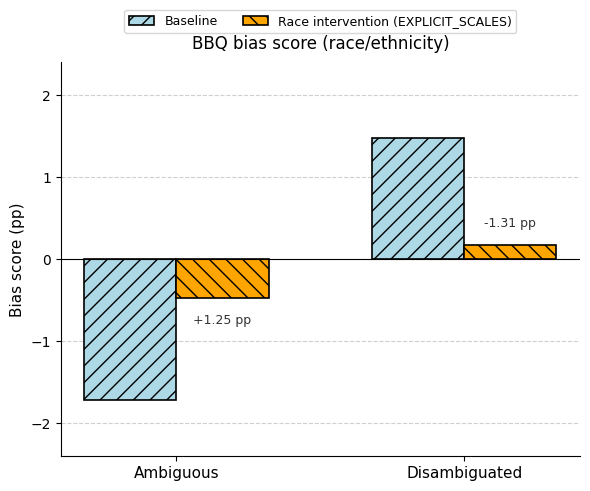

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

contexts = ["Ambiguous", "Disambiguated"]
x = np.arange(len(contexts))
bar_width = 0.32

bias_baseline = [baseline_bbq["amb_bias_score_race"] * 100,
                 baseline_bbq["disamb_bias_score_race"] * 100]
bias_race     = [race_bbq["amb_bias_score_race"] * 100,
                 race_bbq["disamb_bias_score_race"] * 100]

fig, ax = plt.subplots(figsize=(6, 5))

bars_baseline = ax.bar(
    x - bar_width / 2, bias_baseline,
    width=bar_width,
    color="lightblue", edgecolor="black", linewidth=1.2, hatch="//",
    label="Baseline",
)
bars_race = ax.bar(
    x + bar_width / 2, bias_race,
    width=bar_width,
    color="orange", edgecolor="black", linewidth=1.2, hatch="\\\\",
    label="Race intervention (EXPLICIT_SCALES)",
)

bound = max(0.05, max(abs(v) for v in bias_baseline + bias_race) * 1.4)
ax.set_ylim(-bound, bound)
ax.axhline(0, color="black", linewidth=0.8)

y_span = ax.get_ylim()[1] - ax.get_ylim()[0]
label_offset = 0.04 * y_span

for base_val, bar in zip(bias_baseline, bars_race):
    delta = bar.get_height() - base_val
    going_up = bar.get_height() >= 0
    y_text = (
      bar.get_height() + label_offset
      if going_up
      else bar.get_height() - label_offset
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2, y_text, f"{delta:+.2f} pp",
        ha="center", va="bottom" if going_up else "top",
        fontsize=9, color="#333333",
    )

ax.set_xticks(x)
ax.set_xticklabels(contexts, fontsize=11)
ax.set_ylabel("Bias score (pp)", fontsize=11)
ax.set_title("BBQ bias score (race/ethnicity)", fontsize=12, pad=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)

plt.tight_layout()
plt.savefig("bbq_race_ethnicity_results.png", dpi=150, bbox_inches="tight")
plt.show()

This run used BBQ_LIMIT = 25000, to cover the Race_ethnicity category. The category runs intact from index 15,564 to 22,444, so `amb_bias_score_race` and `disamb_bias_score_race` remain computed only over those 6,880 examples.

In the ambiguous context, the bias score moves from −1.72% at baseline to −0.47% after the intervention, a change of +1.25pp, about 73% of the baseline magnitude. In the disambiguated context, the bias score moves from +1.48% to +0.17%, a change of −1.31pp, about 88% of the baseline magnitude. Both context scores move substantially toward zero, the five neurons reduce bias magnitude in both contexts, more strongly in the disambiguated one.

In [ ]:
import json
from datetime import datetime, timezone

print("=" * 70)
print(f"Timestamp (UTC): {datetime.now(timezone.utc).isoformat()}")
print(f"BBQ_LIMIT: {BBQ_LIMIT}")
print("=" * 70)

if "baseline_bbq" in globals():
    print("\n--- BASELINE BBQ RESULTS ---")
    print("baseline_bbq = {")
    for key, value in baseline_bbq.items():
        print(f'    "{key}": {value!r},')
    print("}")
    print(json.dumps(baseline_bbq, indent=2))
else:
    print("\nbaseline_bbq not computed yet.")

if "race_bbq" in globals():
    print("\n--- RACE-INTERVENED BBQ RESULTS ---")
    print("race_bbq = {")
    for key, value in race_bbq.items():
        print(f'    "{key}": {value!r},')
    print("}")
    print(json.dumps(race_bbq, indent=2))

    if "baseline_bbq" in globals():
        print("\n--- Deltas (race minus baseline) ---")
        for key in race_bbq:
            if key in baseline_bbq:
                delta = race_bbq[key] - baseline_bbq[key]
                print(
                    f"  {key}: "
                    f"baseline={baseline_bbq[key]:+.4f}  "
                    f"race={race_bbq[key]:+.4f}  "
                    f"delta={delta:+.4f}"
                )
else:
    print("\nrace_bbq not computed yet.")

print("=" * 70)

Timestamp (UTC): 2026-08-20T22:19:31.241331+00:00
BBQ_LIMIT: 25000

--- BASELINE BBQ RESULTS ---
baseline_bbq = {
    "acc": 0.29296,
    "amb_bias_score_race": np.float64(-0.017151162790697685),
    "disamb_bias_score_race": np.float64(0.014847161572052459),
}
{
  "acc": 0.29296,
  "amb_bias_score_race": -0.017151162790697685,
  "disamb_bias_score_race": 0.014847161572052459
}

--- RACE-INTERVENED BBQ RESULTS ---
race_bbq = {
    "acc": 0.29244,
    "amb_bias_score_race": np.float64(-0.004651162790697726),
    "disamb_bias_score_race": np.float64(0.0017472335468839972),
}
{
  "acc": 0.29244,
  "amb_bias_score_race": -0.004651162790697726,
  "disamb_bias_score_race": 0.0017472335468839972
}

--- Deltas (race minus baseline) ---
  acc: baseline=+0.2930  race=+0.2924  delta=-0.0005
  amb_bias_score_race: baseline=-0.0172  race=-0.0047  delta=+0.0125
  disamb_bias_score_race: baseline=+0.0148  race=+0.0017  delta=-0.0131


In [ ]:
from datasets import load_dataset

ds = load_dataset("oskarvanderwal/bbq", "All", split="test")
categories = ds["category"]

seen = {}
for i, cat in enumerate(categories):
    if cat not in seen:
        seen[cat] = i

for cat, first_idx in sorted(seen.items(), key=lambda kv: kv[1]):
    print(f"{cat:<25} first appears at index {first_idx}")

print(f"\nTotal examples: {len(categories)}")

Age                       first appears at index 0
Disability_status         first appears at index 3680
Gender_identity           first appears at index 5236
Nationality               first appears at index 10908
Physical_appearance       first appears at index 13988
Race_ethnicity            first appears at index 15564
Race_x_SES                first appears at index 22444
Race_x_gender             first appears at index 33604
Religion                  first appears at index 49564
SES                       first appears at index 50764
Sexual_orientation        first appears at index 57628

Total examples: 58492
